# TEC 2D Mapping and Analysis Pipeline

This notebook performs end-to-end processing, analysis, and visualization of GNSS-derived ionospheric Total Electron Content (TEC) data.

### Tools Used:
- **Pandas** for data handling
- **Matplotlib** for visualization
- **NumPy** for numerical operations
- **GeoPandas** for spatial plotting
- **Datetime** for timestamp conversions

---

## 1. Read Raw TEC Data Files (.dat)
Load and clean GNSS-derived TEC observation files.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def read_tec_data(file_path):
    """Read TEC data file and return a pandas DataFrame."""
    columns = ['Week', 'GPS_TOW', 'PRN', 'Az', 'Elv', 'L1CN0', 'S4', 'S4Cor', 
              'TEC30', 'TECRate30', 'L1LockTime', 'L2LockTime', 'L2CN0']
    
    df = pd.read_csv(file_path, names=columns, delimiter=',')
    
    # Convert relevant columns to numeric (you can add more if needed)
    for col in ['TEC30', 'TECRate30', 'GPS_TOW', 'Az', 'Elv', 'S4']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Path to the data directory
data_dir = "../Data/TEC_2D_Data/One_Day_Data"

# Get all .dat files
data_files = glob.glob(os.path.join(data_dir, "*.dat"))

for file_path in data_files:
    # Extract station ID from filename
    station_id = os.path.basename(file_path).split('_')[0]
    
    # Read data
    print(f"Processing station {station_id}...")
    data = read_tec_data(file_path)

    # Print basic statistics
    print(f"\nStation {station_id} Statistics:")
    print(f"Number of satellites: {len(data['PRN'].unique())}")
    print(f"Time span: {data['GPS_TOW'].max() - data['GPS_TOW'].min()} seconds")
    print(f"Average TEC: {data['TEC30'].mean():.2f} TECU")
    print(f"Max TEC: {data['TEC30'].max():.2f} TECU")
    print(f"Min TEC: {data['TEC30'].min():.2f} TECU")
    print("-" * 50)


Processing station 124...

Station 124 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 33.91 TECU
Max TEC: 139.99 TECU
Min TEC: 0.00 TECU
--------------------------------------------------
Processing station 212...

Station 212 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 32.39 TECU
Max TEC: 141.03 TECU
Min TEC: 0.00 TECU
--------------------------------------------------
Processing station 213...

Station 213 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 32.18 TECU
Max TEC: 117.15 TECU
Min TEC: -4.22 TECU
--------------------------------------------------
Processing station 214...

Station 214 Statistics:
Number of satellites: 30
Time span: 86400.0 seconds
Average TEC: 31.82 TECU
Max TEC: 156.96 TECU
Min TEC: -9.90 TECU
--------------------------------------------------
Processing station 301...

Station 301 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 52.32 TECU

## 2. Compute IPP Lat/Lon and ECA using Geometric Formulas

### ✅ **Formulas** 

1. **ECA**:

   $$
   \text{eca} = \frac{\pi}{2} - \text{el}_{\text{sat}} - \sin^{-1} \left( \frac{r_e \cdot \cos(\text{el}_{\text{sat}})}{r_e + h_I} \right)
   $$

2. **IPP\_lat**:

   $$
   \text{IPP}_{\text{lat}} = \sin^{-1} \left( \sin(R_{\text{lat}})\cos(\text{eca}) + \cos(R_{\text{lat}})\sin(\text{eca})\cos(\text{az}_{\text{sat}}) \right)
   $$

3. **IPP\_lon**:

   $$
   \text{IPP}_{\text{lon}} = R_{\text{lon}} + \frac{\sin^{-1}(\sin(\text{eca}) \cdot \sin(\text{az}_{\text{sat}}))}{\cos(\text{IPP}_{\text{lat}})}
   $$

### 📌 Required Parameters

* `el_sat` → `Elv` column (in degrees) → convert to radians
* `az_sat` → `Az` column (in degrees) → convert to radians
* `R_lat`, `R_lon` → receiver (station) lat/lon (constants per file or passed externally)
* `r_e` = 6371 km (mean Earth radius)
* `h_I` = 350 km (typical ionospheric shell height)

---

In [24]:
import pandas as pd
import numpy as np
import glob, os

def read_tec_data(file_path):
    columns = ['Week', 'GPS_TOW', 'PRN', 'Az', 'Elv', 'L1CN0', 'S4', 'S4Cor', 
               'TEC30', 'TECRate30', 'L1LockTime', 'L2LockTime', 'L2CN0']
    df = pd.read_csv(file_path, names=columns, delimiter=',', skiprows=1)
    for col in ['Az', 'Elv', 'TEC30', 'TECRate30', 'GPS_TOW', 'S4']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def compute_ipp(df, R_lat_deg, R_lon_deg, h_I=350, r_e=6371):
    # Convert degrees to radians
    R_lat = np.radians(R_lat_deg)
    R_lon = np.radians(R_lon_deg)
    el = np.radians(df['Elv'])
    az = np.radians(df['Az'])

    # ECA calculation
    term = (r_e * np.cos(el)) / (r_e + h_I)
    eca = (np.pi / 2) - el - np.arcsin(term)

    # IPP latitude
    IPP_lat = np.arcsin(np.sin(R_lat) * np.cos(eca) + 
                        np.cos(R_lat) * np.sin(eca) * np.cos(az))

    # IPP longitude
    delta_lon = np.arcsin(np.sin(eca) * np.sin(az)) / np.cos(IPP_lat)
    IPP_lon = R_lon + delta_lon

    # Convert radians to degrees
    df['ECA'] = np.degrees(eca)
    df['IPP_lat'] = np.degrees(IPP_lat)
    df['IPP_lon'] = np.degrees(IPP_lon)
    return df

# ---- MAIN SCRIPT ----
data_dir = "../Data/TEC_2D_Data/One_Day_Data"
output_dir = "../Data/GenData/Processed_TEC_with_IPP"
os.makedirs(output_dir, exist_ok=True)

data_files = glob.glob(os.path.join(data_dir, "*.dat"))

# 🔧 You must set the receiver's latitude and longitude for each station
station_coords = {
    "124": (31.10, 77.17),   # Shimla
    "212": (28.61, 77.20),   # Delhi
    "213": (26.24, 73.02),   # Jodhpur
    "214": (26.85, 80.95),   # Lucknow
    "301": (26.70, 88.35),   # Bagdogra
    "302": (26.14, 91.77),   # Guwahati
    "305": (23.72, 92.72),   # Aizawl
    "306": (23.03, 72.58),   # Ahmedabad
    "307": (23.25, 77.41),   # Bhopal
    "308": (21.25, 81.63),   # Raipur
    "309": (22.57, 88.36),   # Kolkata
    "310": (19.07, 72.87),   # Mumbai
    "311": (17.39, 78.49),   # Hyderabad
    "313": (17.69, 83.22),   # Visakhapatnam
    "315": (12.97, 77.59),   # Bangalore
    "316": (8.49, 76.95),    # Trivandrum
}

for file_path in data_files:
    station_id = os.path.basename(file_path).split('_')[0]
    print(f"Processing station {station_id}...")

    data = read_tec_data(file_path)

    # Get station lat/lon or default
    R_lat, R_lon = station_coords.get(station_id, (23.0, 78.0))  # default to MP center

    # Compute IPP and ECA
    data = compute_ipp(data, R_lat, R_lon)

    # Save to new directory
    new_file = os.path.join(output_dir, f"{station_id}_with_IPP.csv")
    data.to_csv(new_file, index=False)
    print(f"Saved processed file to: {new_file}")


Processing station 124...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\124_with_IPP.csv
Processing station 212...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\212_with_IPP.csv
Processing station 213...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\213_with_IPP.csv
Processing station 214...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\214_with_IPP.csv
Processing station 301...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\301_with_IPP.csv
Processing station 302...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\302_with_IPP.csv
Processing station 305...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\305_with_IPP.csv
Processing station 306...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\306_with_IPP.csv
Processing station 307...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\307_with_IPP.csv
Processing station 308...
Saved proce

## 3. Convert GPS Time of Week to UTC and IST

GPS Time (since 2005-04-03) → UTC → IST

In [1]:
import pandas as pd
import numpy as np
import glob
import os
from datetime import datetime, timedelta, timezone

# Constants
GPS_EPOCH = datetime(1980, 1, 6, tzinfo=timezone.utc)
LEAP_SECONDS = 18  # As of 2024 (may update if GPS time advances)

def gps_to_utc(gps_week, tow_seconds):
    """Convert GPS Week + Time of Week to UTC datetime."""
    gps_time = GPS_EPOCH + timedelta(weeks=gps_week, seconds=tow_seconds)
    utc_time = gps_time - timedelta(seconds=LEAP_SECONDS)
    return utc_time

def utc_to_ist(utc_dt):
    """Convert UTC datetime to IST datetime."""
    return utc_dt + timedelta(hours=5, minutes=30)

# Paths
input_dir = "../Data/GenData/Processed_TEC_with_IPP"
output_dir = "../Data/GenData/Processed_TEC_with_IPP_Timestamps"
os.makedirs(output_dir, exist_ok=True)

# Process all files
for file_path in glob.glob(os.path.join(input_dir, "*.csv")):
    df = pd.read_csv(file_path)
    
    if df.empty:
        continue

    # Apply elevation filter
    df = df[df['Elv'] >= 25]
    
    print(f"Processing timestamps for {os.path.basename(file_path)}...")

    # Compute UTC and IST datetime columns
    df['UTC_time'] = [gps_to_utc(w, tow) for w, tow in zip(df['Week'], df['GPS_TOW'])]
    df['IST_time'] = [utc_to_ist(utc) for utc in df['UTC_time']]
    
    # Save to new file
    filename = os.path.basename(file_path)
    df.to_csv(os.path.join(output_dir, filename), index=False)

    print(f"✅ Saved: {filename} with UTC and IST columns added.")


Processing timestamps for 124_with_IPP.csv...
✅ Saved: 124_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 212_with_IPP.csv...
✅ Saved: 212_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 213_with_IPP.csv...
✅ Saved: 213_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 214_with_IPP.csv...
✅ Saved: 214_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 301_with_IPP.csv...
✅ Saved: 301_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 302_with_IPP.csv...
✅ Saved: 302_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 305_with_IPP.csv...
✅ Saved: 305_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 306_with_IPP.csv...
✅ Saved: 306_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 307_with_IPP.csv...
✅ Saved: 307_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 308_with_IPP.csv...
✅ Saved: 308_with_

## 4. Visualization of TEC, S4, TEC Rate, and Sky Plots
- TEC vs Time
- S4 Scintillation vs Time
- Polar Sky Plot (Azimuth vs Elevation)
- TEC Rate vs Time

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates
import glob
import os
import numpy as np

# Function to read data and apply elevation filter
def read_tec_data(file_path):
    df = pd.read_csv(file_path, parse_dates=['IST_time'])  # Parse IST_time as datetime
    
    # Convert required columns to numeric
    for col in ['Az', 'Elv', 'TEC30', 'TECRate30', 'S4']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Function to create and save all 4 plots
def plot_tec_data(data, station_id, base_output="../Output"):
    unique_prns = sorted(data['PRN'].unique())
    cmap = cm.get_cmap('tab20', len(unique_prns))

    # Create output subfolders
    os.makedirs(os.path.join(base_output, "TEC_TimeSeries"), exist_ok=True)
    os.makedirs(os.path.join(base_output, "S4_Scintillation"), exist_ok=True)
    os.makedirs(os.path.join(base_output, "Sky_Plot"), exist_ok=True)
    os.makedirs(os.path.join(base_output, "TEC_Rate"), exist_ok=True)

    # ---------- Plot 1: TEC Time Series ----------
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    for i, prn in enumerate(unique_prns):
        prn_data = data[data['PRN'] == prn]
        ax1.scatter(prn_data['IST_time'], prn_data['TEC30'], label=f'PRN {prn}', s=12, color=cmap(i))
    ax1.set_title(f'TEC Values Over Time - Station {station_id}')
    ax1.set_xlabel('IST Time')
    ax1.set_ylabel('TEC (TECU)')
    ax1.set_ylim(0, 120)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.2)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    fig1.autofmt_xdate()
    fig1.tight_layout()
    fig1.savefig(os.path.join(base_output, "TEC_TimeSeries", f"{station_id}_tec.png"), dpi=300, bbox_inches='tight')
    plt.close(fig1)

    # ---------- Plot 2: S4 Scintillation ----------
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    for i, prn in enumerate(unique_prns):
        prn_data = data[data['PRN'] == prn]
        ax2.scatter(prn_data['IST_time'], prn_data['S4'], label=f'PRN {prn}', s=12, color=cmap(i))
    ax2.set_title(f'S4 Scintillation Index - Station {station_id}')
    ax2.set_xlabel('IST Time')
    ax2.set_ylabel('S4 Index')
    ax2.set_ylim(0, 1.5)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.2)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    fig2.autofmt_xdate()
    fig2.tight_layout()
    fig2.savefig(os.path.join(base_output, "S4_Scintillation", f"{station_id}_s4.png"), dpi=300, bbox_inches='tight')
    plt.close(fig2)

    # ---------- Plot 3: Polar Sky Plot ----------
    fig3 = plt.figure(figsize=(8, 8))
    ax3 = fig3.add_subplot(111, polar=True)
    az_rad = np.radians(data['Az'])
    el_adj = 90 - data['Elv']
    sc = ax3.scatter(az_rad, el_adj, c=data['TEC30'], cmap='jet', s=20)
    ax3.set_title(f'Polar Sky Plot - Station {station_id}', pad=20)
    plt.colorbar(sc, ax=ax3, label='TEC (TECU)', pad=0.1)
    ax3.set_theta_zero_location('N')
    ax3.set_theta_direction(-1)
    ax3.set_rgrids([0, 30, 60], labels=["90°", "60°", "30°"], angle=22.5)
    ax3.set_thetagrids(range(0, 360, 45), labels=[f'{ang}°' for ang in range(0, 360, 45)])
    fig3.tight_layout()
    fig3.savefig(os.path.join(base_output, "Sky_Plot", f"{station_id}_sky.png"), dpi=300, bbox_inches='tight')
    plt.close(fig3)

    # ---------- Plot 4: TEC Rate ----------
    fig4, ax4 = plt.subplots(figsize=(10, 6))
    for i, prn in enumerate(unique_prns):
        prn_data = data[data['PRN'] == prn]
        ax4.scatter(prn_data['IST_time'], prn_data['TECRate30'], label=f'PRN {prn}', s=12, color=cmap(i))
    ax4.set_title(f'TEC Rate - Station {station_id}')
    ax4.set_xlabel('IST Time')
    ax4.set_ylabel('TEC Rate (TECU/min)')
    ax4.set_ylim(-1.5, 1.5)
    ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.2)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax4.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    fig4.autofmt_xdate()
    fig4.tight_layout()
    fig4.savefig(os.path.join(base_output, "TEC_Rate", f"{station_id}_tec_rate.png"), dpi=300, bbox_inches='tight')
    plt.close(fig4)

# -----------------------------
# Main script
# -----------------------------
data_dir = "../Data/GenData/Processed_TEC_with_VTEC"
data_files = glob.glob(os.path.join(data_dir, "*.csv"))

for file_path in data_files:
    station_id = os.path.basename(file_path).split('_')[0]
    print(f"Processing station {station_id}...")
    
    data = read_tec_data(file_path)
    
    if data.empty:
        print(f"⚠️  Station {station_id}: No valid data after elevation filter. Skipping...\n" + "-"*50)
        continue

    # Generate plots
    plot_tec_data(data, station_id)
    
    # Print stats
    print(f"\nStation {station_id} Statistics:")
    print(f"Number of satellites: {len(data['PRN'].unique())}")
    print(f"Time span: {data['IST_time'].min()} to {data['IST_time'].max()}")
    print(f"Average TEC: {data['TEC30'].mean():.2f} TECU")
    print(f"Max TEC: {data['TEC30'].max():.2f} TECU")
    print(f"Min TEC: {data['TEC30'].min():.2f} TECU")
    print("-" * 50)


Processing station 124...


C:\Users\hp\AppData\Local\Temp\ipykernel_24516\1538862183.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 124 Statistics:
Number of satellites: 28
Time span: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
Average TEC: 31.70 TECU
Max TEC: 114.96 TECU
Min TEC: 3.00 TECU
--------------------------------------------------
Processing station 212...


C:\Users\hp\AppData\Local\Temp\ipykernel_24516\1538862183.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 212 Statistics:
Number of satellites: 28
Time span: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
Average TEC: 30.83 TECU
Max TEC: 116.52 TECU
Min TEC: 3.00 TECU
--------------------------------------------------
Processing station 213...


...


Station 313 Statistics:
Number of satellites: 28
Time span: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
Average TEC: 41.14 TECU
Max TEC: 115.76 TECU
Min TEC: 3.00 TECU
--------------------------------------------------
Processing station 315...


C:\Users\hp\AppData\Local\Temp\ipykernel_24516\1538862183.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 315 Statistics:
Number of satellites: 28
Time span: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
Average TEC: 37.92 TECU
Max TEC: 98.89 TECU
Min TEC: 3.00 TECU
--------------------------------------------------
Processing station 316...


C:\Users\hp\AppData\Local\Temp\ipykernel_24516\1538862183.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 316 Statistics:
Number of satellites: 28
Time span: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
Average TEC: 35.60 TECU
Max TEC: 92.88 TECU
Min TEC: 3.00 TECU
--------------------------------------------------


## 5. IPP Plot from all stations on India Map
[TODO] - Use Proper Jet Coloring

C:\Users\hp\AppData\Local\Temp\ipykernel_24516\1816198061.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('jet')


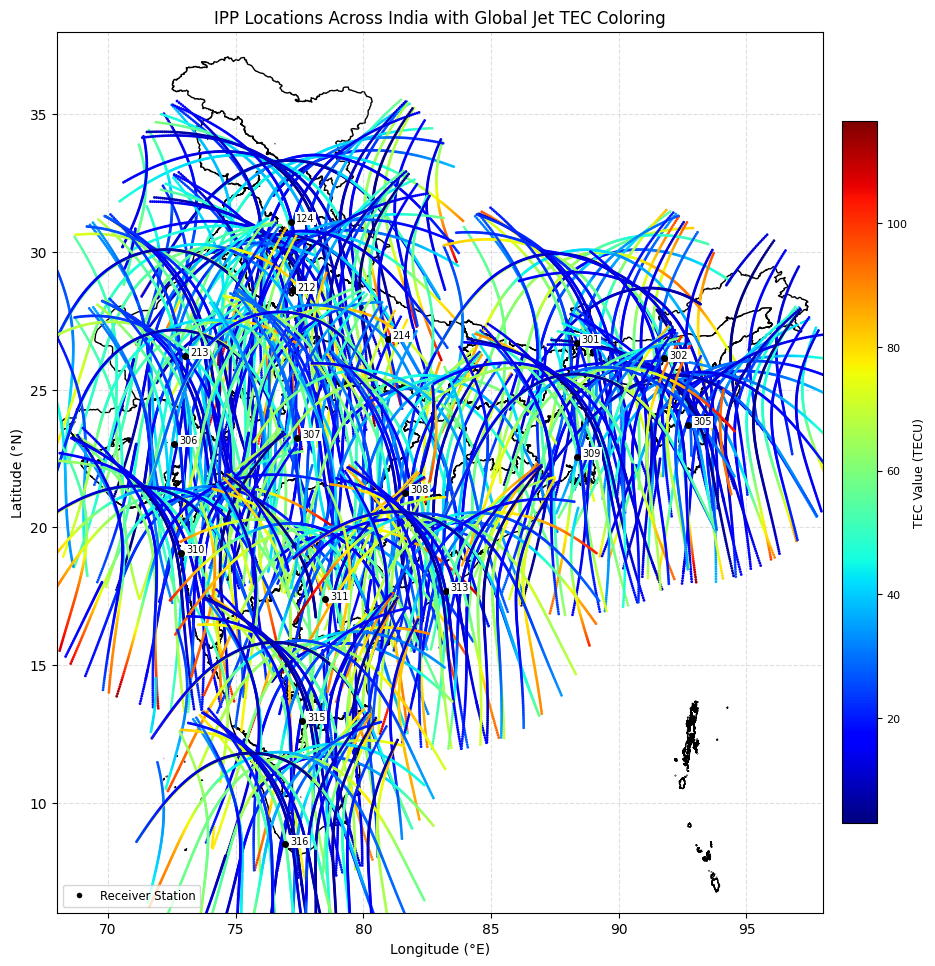

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap

# Load India shapefile
shapefile_path = "../Data/shapefiles/STATE_BOUNDARY.shp"
gdf = gpd.read_file(shapefile_path)
if gdf.crs is None or gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)

# Updated station coordinates (matched to 16 site IDs)
station_coords = {
    "124": (31.10, 77.17),   # Shimla
    "212": (28.61, 77.20),   # Delhi
    "213": (26.24, 73.02),   # Jodhpur
    "214": (26.85, 80.95),   # Lucknow
    "301": (26.70, 88.35),   # Bagdogra
    "302": (26.14, 91.77),   # Guwahati
    "305": (23.72, 92.72),   # Aizawl
    "306": (23.03, 72.58),   # Ahmedabad
    "307": (23.25, 77.41),   # Bhopal
    "308": (21.25, 81.63),   # Raipur
    "309": (22.57, 88.36),   # Kolkata
    "310": (19.07, 72.87),   # Mumbai
    "311": (17.39, 78.49),   # Hyderabad
    "313": (17.69, 83.22),   # Visakhapatnam
    "315": (12.97, 77.59),   # Bangalore
    "316": (8.49, 76.95),    # Trivandrum
}

# Gather all IPP points and their TEC values
ipp_data_dir = "../Data/GenData/Processed_TEC_with_VTEC"
ipp_files = glob.glob(os.path.join(ipp_data_dir, "*.csv"))

all_df = []
for file in ipp_files:
    df = pd.read_csv(file)
    df = df.dropna(subset=['IPP_lat', 'IPP_lon', 'TEC30'])
    all_df.append(df[['IPP_lat', 'IPP_lon', 'TEC30']])

combined_df = pd.concat(all_df, ignore_index=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
gdf.plot(ax=ax, color='white', edgecolor='black')

# Use official Jet colormap
norm = Normalize(vmin=combined_df['TEC30'].min(), vmax=combined_df['TEC30'].max())
cmap = get_cmap('jet')
sc = ax.scatter(combined_df['IPP_lon'], combined_df['IPP_lat'], c=combined_df['TEC30'], 
                cmap=cmap, norm=norm, s=1, alpha=1, zorder=2)

# Plot station markers
for station, (lat, lon) in station_coords.items():
    ax.plot(lon, lat, 'ko', markersize=4, zorder=4, label='_nolegend_')
    ax.text(lon + 0.2, lat, station, fontsize=7, color='black',
            bbox=dict(facecolor='white', edgecolor='none', pad=1), zorder=5)

# Add shared colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('TEC Value (TECU)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Add custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Receiver Station', markerfacecolor='black', markersize=5),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize='small')

# Final plot aesthetics
ax.set_title("IPP Locations Across India with Global Jet TEC Coloring")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_xlim(68, 98)
ax.set_ylim(6, 38)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Save the output
plt.savefig("../Output/IPP_Map_GlobalJet_TECColor.png", dpi=300, bbox_inches='tight')
plt.show()


### 24 Hr IPP Plot

C:\Users\hp\AppData\Local\Temp\ipykernel_24516\3091121278.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


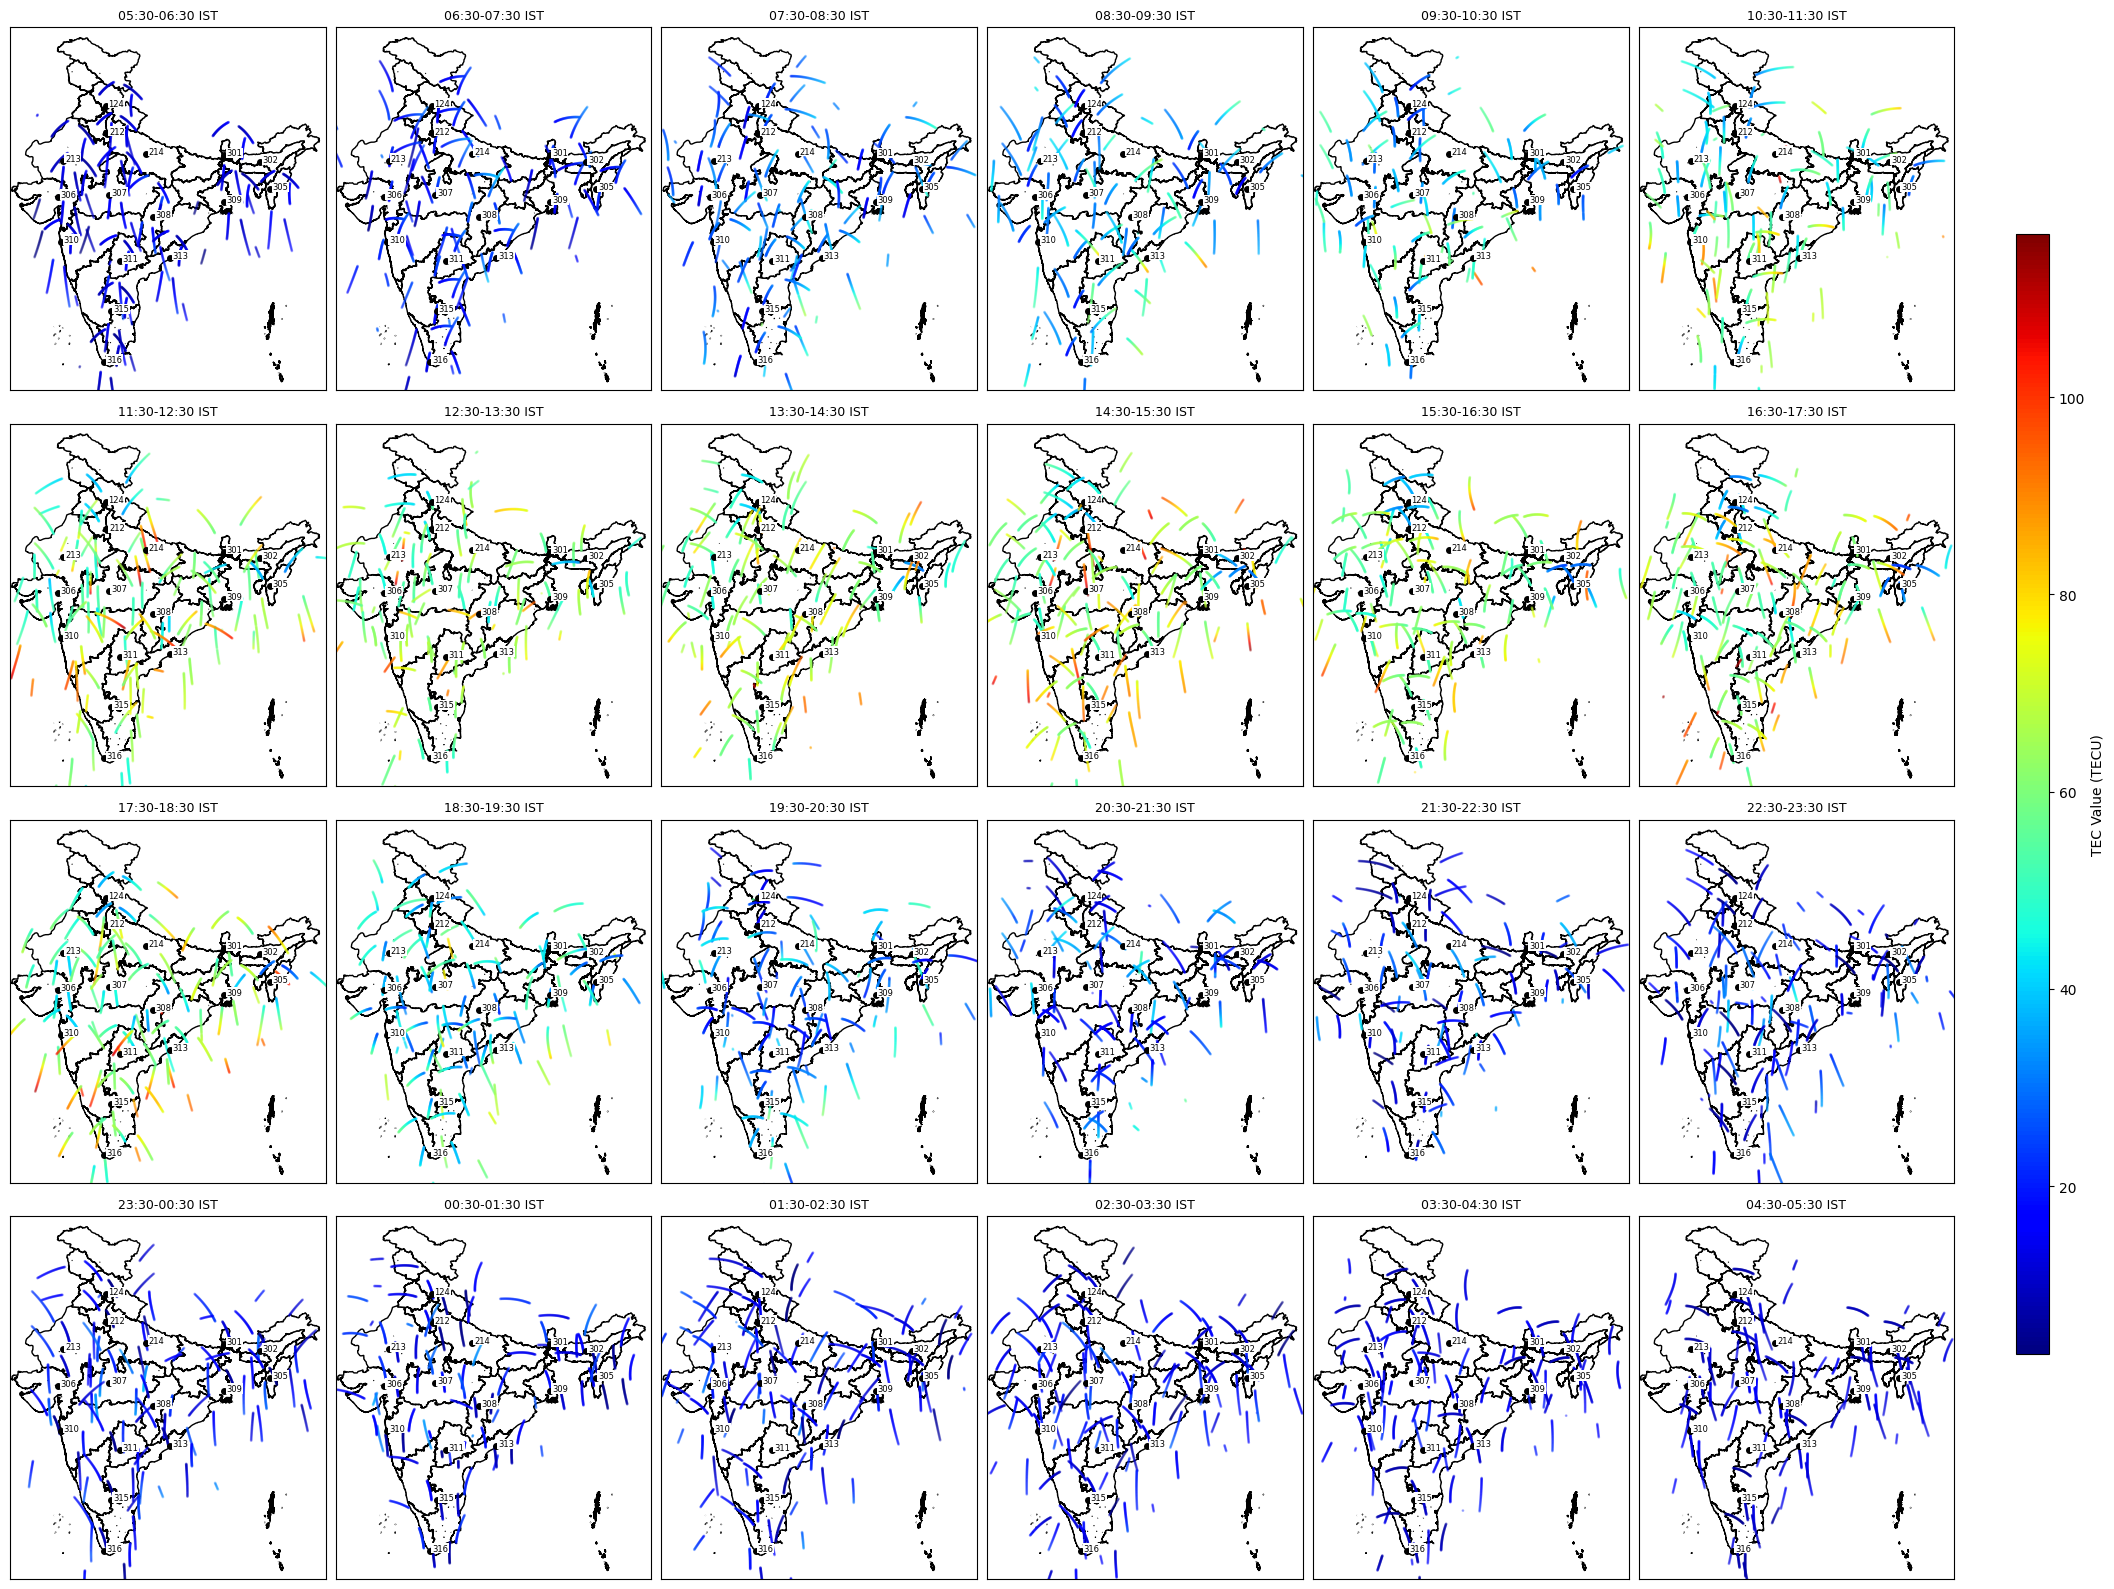

✅ Saved 24-hour IPP grid with 6×4 layout.


In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from datetime import datetime, timedelta

# Load India shapefile
gdf = gpd.read_file("../Data/shapefiles/STATE_BOUNDARY.shp")
if gdf.crs is None or gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)

# Load and prepare IPP data
ipp_data_dir = "../Data/GenData/Processed_TEC_with_VTEC"
ipp_files = glob.glob(os.path.join(ipp_data_dir, "*.csv"))
all_df = []
for file in ipp_files:
    df = pd.read_csv(file, parse_dates=['IST_time'])
    df = df.dropna(subset=['IPP_lat', 'IPP_lon', 'TEC30'])
    all_df.append(df[['IPP_lat', 'IPP_lon', 'TEC30', 'IST_time']])
combined_df = pd.concat(all_df, ignore_index=True)
combined_df['IST_time'] = pd.to_datetime(combined_df['IST_time']).dt.tz_localize(None)

# Jet colormap normalization
vmin, vmax = combined_df['TEC30'].min(), combined_df['TEC30'].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.colormaps.get_cmap('jet')

# Subplot grid 6x4
start_time = pd.to_datetime("2005-04-03 05:30:00")
fig, axs = plt.subplots(4, 6, figsize=(22, 16))
axs = axs.flatten()

# Receiver locations
station_coords = {
    "124": (31.10, 77.17), "212": (28.61, 77.20), "213": (26.24, 73.02), "214": (26.85, 80.95),
    "301": (26.70, 88.35), "302": (26.14, 91.77), "305": (23.72, 92.72), "306": (23.03, 72.58),
    "307": (23.25, 77.41), "308": (21.25, 81.63), "309": (22.57, 88.36), "310": (19.07, 72.87),
    "311": (17.39, 78.49), "313": (17.69, 83.22), "315": (12.97, 77.59), "316": (8.49, 76.95),
}

# Plot hourly subplots
for hour in range(24):
    ax = axs[hour]
    window_start = start_time + timedelta(hours=hour)
    window_end = window_start + timedelta(hours=1)
    hourly_df = combined_df[(combined_df['IST_time'] >= window_start) & (combined_df['IST_time'] < window_end)]

    gdf.plot(ax=ax, color='white', edgecolor='black')
    if not hourly_df.empty:
        ax.scatter(hourly_df['IPP_lon'], hourly_df['IPP_lat'], c=hourly_df['TEC30'],
                   cmap=cmap, norm=norm, s=1, alpha=0.3)

    for station, (lat, lon) in station_coords.items():
        ax.plot(lon, lat, 'ko', markersize=4)
        ax.text(lon + 0.2, lat, station, fontsize=6, color='black',
                bbox=dict(facecolor='white', edgecolor='none', pad=0.5))

    label = f"{window_start.strftime('%H:%M')}-{window_end.strftime('%H:%M')} IST"
    ax.set_title(label, fontsize=9)
    ax.set_xlim(68, 98)
    ax.set_ylim(6, 38)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

# Hide unused axes if any
for i in range(24, len(axs)):
    fig.delaxes(axs[i])

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('TEC Value (TECU)', fontsize=10)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("../Output/IPP_Hourly_Grid_JetMap_6x4.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved 24-hour IPP grid with 6×4 layout.")

## 6. Slant TEC to Vertical TEC Conversion

In this step, we apply a **mapping function** to convert Slant TEC (STEC) values to **Vertical TEC (VTEC)** values. This corrects for the satellite's elevation angle, accounting for the increased path length at lower elevations.

### Mapping Function:
Using the Single Layer Mapping Function (SLMF):

$$
VTEC = STEC \times \cos(E') = \text{STEC} \cdot \left(1 - \left( \frac{R_e \cdot \cos(Elv)}{R_e + h_I} \right)^2 \right)^{1/2}
$$

Where:
- $Elv$ is satellite elevation angle in radians
- $R_e = 6371$ km is Earth's radius
- $h_I = 350$ km is ionospheric shell height

In [10]:
import pandas as pd
import numpy as np
import glob
import os

# Constants
R_e = 6371  # Earth radius in km
h_I = 350   # Ionospheric shell height in km

# Input/output paths
input_dir = "../Data/GenData/Processed_TEC_with_IPP_Timestamps"
output_dir = "../Data/GenData/Processed_TEC_with_VTEC"
os.makedirs(output_dir, exist_ok=True)

# Function to convert STEC to VTEC
def compute_vtec(df):
    el_rad = np.radians(df['Elv'])
    mapping_function = np.sqrt(1 - ( (R_e * np.cos(el_rad)) / (R_e + h_I) )**2 )
    df['VTEC'] = df['TEC30'] * mapping_function
    return df

# Process each file and compute VTEC
for file_path in glob.glob(os.path.join(input_dir, "*.csv")):
    df = pd.read_csv(file_path)
    if df.empty or 'Elv' not in df or 'TEC30' not in df:
        continue

    print(f"Processing VTEC for {os.path.basename(file_path)}")
    df = df.dropna(subset=['Elv', 'TEC30'])
    df = compute_vtec(df)

    # Save output with new VTEC column
    filename = os.path.basename(file_path)
    output_file = os.path.join(output_dir, filename)
    df.to_csv(output_file, index=False)
    print(f"✅ Saved VTEC file: {filename}")


Processing VTEC for 124_with_IPP.csv
✅ Saved VTEC file: 124_with_IPP.csv
Processing VTEC for 212_with_IPP.csv
✅ Saved VTEC file: 212_with_IPP.csv
Processing VTEC for 213_with_IPP.csv
✅ Saved VTEC file: 213_with_IPP.csv
Processing VTEC for 301_with_IPP.csv
✅ Saved VTEC file: 301_with_IPP.csv
Processing VTEC for 302_with_IPP.csv
✅ Saved VTEC file: 302_with_IPP.csv
Processing VTEC for 305_with_IPP.csv
✅ Saved VTEC file: 305_with_IPP.csv
Processing VTEC for 306_with_IPP.csv
✅ Saved VTEC file: 306_with_IPP.csv
Processing VTEC for 307_with_IPP.csv
✅ Saved VTEC file: 307_with_IPP.csv
Processing VTEC for 308_with_IPP.csv
✅ Saved VTEC file: 308_with_IPP.csv
Processing VTEC for 309_with_IPP.csv
✅ Saved VTEC file: 309_with_IPP.csv
Processing VTEC for 310_with_IPP.csv
✅ Saved VTEC file: 310_with_IPP.csv
Processing VTEC for 311_with_IPP.csv
✅ Saved VTEC file: 311_with_IPP.csv
Processing VTEC for 313_with_IPP.csv
✅ Saved VTEC file: 313_with_IPP.csv
Processing VTEC for 315_with_IPP.csv
✅ Saved VTEC f

In [11]:
# ## 6.1 Apply Station-wise TEC Bias Correction (Set Min TEC to 3 TECU)

import pandas as pd
import numpy as np
import glob
import os

input_dir = "../Data/GenData/Processed_TEC_with_VTEC"
output_dir = "../Data/GenData/Processed_TEC_with_VTEC"
os.makedirs(output_dir, exist_ok=True)

MIN_TEC = 3  # Desired minimum TEC level for all stations

for file_path in glob.glob(os.path.join(input_dir, "*.csv")):
    df = pd.read_csv(file_path)

    if df.empty or 'TEC30' not in df:
        continue

    min_tec = df['TEC30'].min()

    # Compute required downward or upward shift to make min TEC = 3
    shift = MIN_TEC - min_tec
    df['TEC30'] = df['TEC30'] + shift

    # Save the bias-corrected file
    filename = os.path.basename(file_path)
    corrected_path = os.path.join(output_dir, filename)
    df.to_csv(corrected_path, index=False)
    print(f"✅ Bias corrected: {filename} (min TEC shifted by {shift:.2f})")


✅ Bias corrected: 124_with_IPP.csv (min TEC shifted by 1.33)
✅ Bias corrected: 212_with_IPP.csv (min TEC shifted by 2.05)
✅ Bias corrected: 213_with_IPP.csv (min TEC shifted by 6.81)
✅ Bias corrected: 301_with_IPP.csv (min TEC shifted by -8.29)
✅ Bias corrected: 302_with_IPP.csv (min TEC shifted by -14.84)
✅ Bias corrected: 305_with_IPP.csv (min TEC shifted by 12.84)
✅ Bias corrected: 306_with_IPP.csv (min TEC shifted by -15.99)
✅ Bias corrected: 307_with_IPP.csv (min TEC shifted by 15.95)
✅ Bias corrected: 308_with_IPP.csv (min TEC shifted by 5.43)
✅ Bias corrected: 309_with_IPP.csv (min TEC shifted by -6.76)
✅ Bias corrected: 310_with_IPP.csv (min TEC shifted by 2.38)
✅ Bias corrected: 311_with_IPP.csv (min TEC shifted by -2.52)
✅ Bias corrected: 313_with_IPP.csv (min TEC shifted by -6.12)
✅ Bias corrected: 315_with_IPP.csv (min TEC shifted by 6.49)
✅ Bias corrected: 316_with_IPP.csv (min TEC shifted by -4.99)


## 7. Gridded VTEC Mapping (Spatial Interpolation)

In this step, we bin the VTEC values spatially into lat-lon grid cells to create gridded maps over India.

### Procedure:
- Choose grid resolution (e.g., 0.5°x0.5°)
- Filter by a specific IST time window (e.g., 15:30 to 16:30)
- Aggregate VTEC values using mean per grid cell
- Visualize with color map and India shapefile overlay

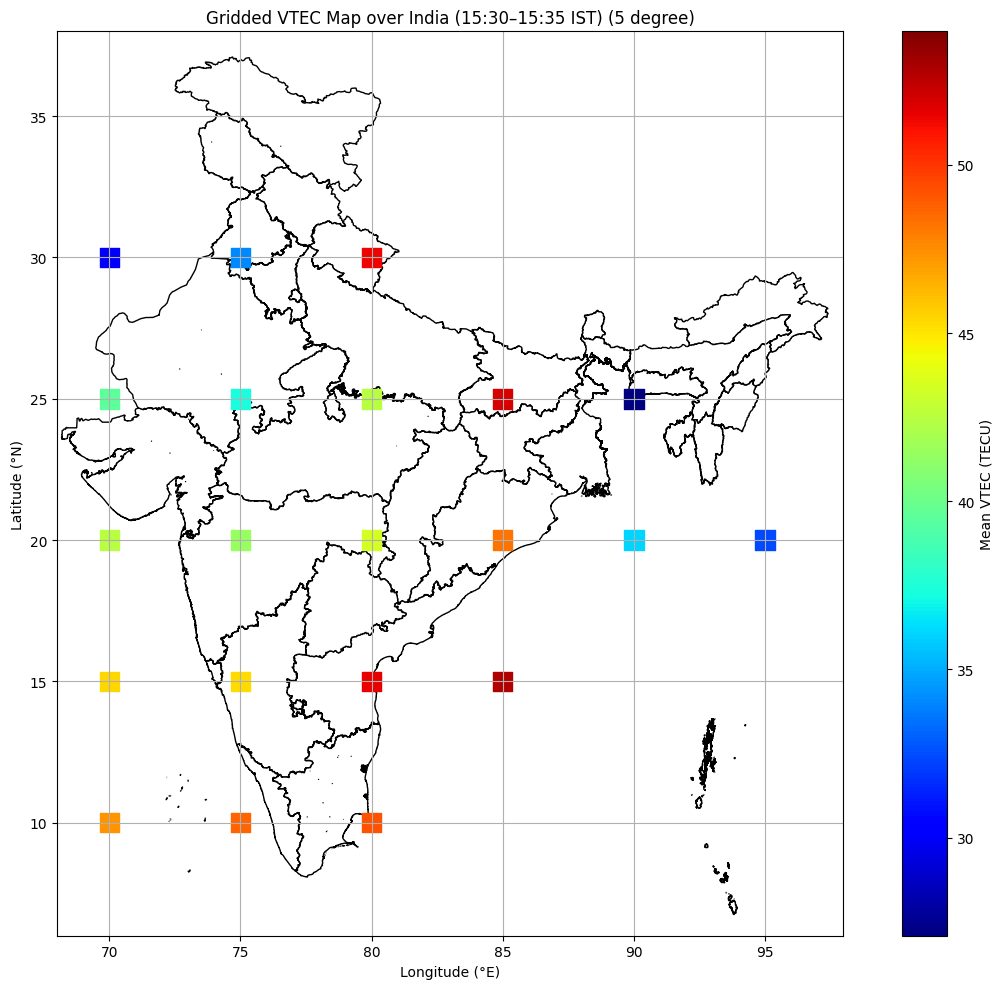

In [13]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Load VTEC data
vtec_dir = "../Data/GenData/Processed_TEC_with_VTEC"
grid_resolution = 5  # in degrees
time_window_start = "2005-04-03 15:30:00"
time_window_end = "2005-04-03 15:35:00"

# Load all files and filter by time
all_data = []
for file_path in glob.glob(os.path.join(vtec_dir, "*.csv")):
    df = pd.read_csv(file_path, parse_dates=['IST_time'])
    df = df[(df['IST_time'] >= time_window_start) & (df['IST_time'] <= time_window_end)]
    df = df.dropna(subset=['IPP_lat', 'IPP_lon', 'VTEC'])
    all_data.append(df[['IPP_lat', 'IPP_lon', 'VTEC']])

vtec_df = pd.concat(all_data, ignore_index=True)

# Bin into lat-lon grid
vtec_df['lat_bin'] = (vtec_df['IPP_lat'] // grid_resolution) * grid_resolution
vtec_df['lon_bin'] = (vtec_df['IPP_lon'] // grid_resolution) * grid_resolution
grid_vtec = vtec_df.groupby(['lat_bin', 'lon_bin'])['VTEC'].mean().reset_index()

# Load India map
shapefile_path = "../Data/shapefiles/STATE_BOUNDARY.shp"
gdf = gpd.read_file(shapefile_path)
if gdf.crs is None or gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)

# Plot gridded VTEC
fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(ax=ax, color='white', edgecolor='black')
sc = ax.scatter(grid_vtec['lon_bin'], grid_vtec['lat_bin'], c=grid_vtec['VTEC'], cmap='jet', s=200, marker='s')

plt.colorbar(sc, label='Mean VTEC (TECU)')
ax.set_title("Gridded VTEC Map over India (15:30–15:35 IST) (5 degree)")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_xlim(68, 98)
ax.set_ylim(6, 38)
ax.grid(True)
plt.tight_layout()
plt.savefig("../Output/VTEC_Gridded_Map_India.png", dpi=300)
plt.show()


In [20]:
# Auto-detect available time range
for file_path in glob.glob(os.path.join(vtec_dir, "*.csv")):
    df = pd.read_csv(file_path, parse_dates=['IST_time'])
    print(f"{os.path.basename(file_path)}: {df['IST_time'].min()} to {df['IST_time'].max()}")


124_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
212_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
213_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
301_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
302_with_IPP.csv: 2005-04-03 23:20:42+00:00 to 2005-04-04 05:29:42+00:00
305_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
306_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
307_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
308_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
309_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
310_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
311_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 00:49:42+00:00
313_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
315_with_IPP.csv: 2005-04-03 05:29:42+00:00 to 2005

## VTEC Time series

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.cm as cm

vtec_dir = "../Data/GenData/Processed_TEC_with_VTEC"
output_dir = "../Output/VTEC_TimeSeries_PerStation"
os.makedirs(output_dir, exist_ok=True)

for file_path in glob.glob(os.path.join(vtec_dir, "*.csv")):
    df = pd.read_csv(file_path, parse_dates=['IST_time'])
    if df.empty:
        continue

    station_id = os.path.basename(file_path).split('_')[0]
    prns = sorted(df['PRN'].dropna().unique())
    cmap = cm.get_cmap('tab20', len(prns))

    # Scatter plot for VTEC time series colored by PRN
    plt.figure(figsize=(10, 6))
    for i, prn in enumerate(prns):
        prn_data = df[df['PRN'] == prn]
        plt.scatter(prn_data['IST_time'], prn_data['VTEC'], label=f'PRN {prn}', s=6, color=cmap(i))

    plt.title(f"VTEC Time Series - Station {station_id}")
    plt.xlabel("IST Time")
    plt.ylabel("VTEC (TECU)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', fontsize='x-small', markerscale=2)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{station_id}_vtec_timeseries.png"), dpi=300)
    plt.close()

print("✅ Colored VTEC scatter plots saved for all stations.")

C:\Users\hp\AppData\Local\Temp\ipykernel_2768\2465949467.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(prns))
C:\Users\hp\AppData\Local\Temp\ipykernel_2768\2465949467.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(prns))
C:\Users\hp\AppData\Local\Temp\ipykernel_2768\2465949467.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(prns))
C:\Users\hp\AppData

✅ Colored VTEC scatter plots saved for all stations.


## ROT and ROTI Definitions:

1. **Rate of TEC (ROT)**:

   $$
   \text{ROT}(t) = \frac{\text{TEC}(t) - \text{TEC}(t - \Delta t)}{\Delta t}
   $$

   where $\Delta t$ is in seconds (30 sec).

2. **Rate of TEC Index (ROTI)**:

   $$
   \text{ROTI}(t) = \sqrt{ \langle \text{ROT}^2 \rangle - \langle \text{ROT} \rangle^2 }
   $$

   over a time window, 5 minutes.



In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Folder containing VTEC-corrected files
vtec_dir = "../Data/GenData/Processed_TEC_with_VTEC"

# Output directory
output_dir = "../Output/ROTI_TimeSeries"
os.makedirs(output_dir, exist_ok=True)

window = 10  # 10-point window for ROTI (~5 min if sampled every 30 sec)

for file_path in glob.glob(os.path.join(vtec_dir, "*.csv")):
    df = pd.read_csv(file_path, parse_dates=['IST_time'])
    station_id = os.path.basename(file_path).split('_')[0]

    if df.empty or 'PRN' not in df or 'VTEC' not in df:
        continue

    df = df.dropna(subset=['VTEC'])
    df.sort_values(['PRN', 'IST_time'], inplace=True)

    df['ROTI'] = np.nan

    # Compute ROTI per PRN
    for prn in df['PRN'].unique():
        prn_df = df[df['PRN'] == prn].copy()
        prn_df['ROT'] = prn_df['VTEC'].diff() / 30.0  # TECU/sec assuming 30 sec sample rate
        prn_df['ROTI'] = prn_df['ROT'].rolling(window=window, min_periods=3).std()
        df.loc[prn_df.index, 'ROTI'] = prn_df['ROTI']

    # Plot ROTI vs IST time (scatter)
    plt.figure(figsize=(10, 6))
    plt.scatter(df['IST_time'], df['ROTI'], label='ROTI', color='red', s=10)
    plt.title(f"ROTI Time Series - Station {station_id}")
    plt.xlabel("IST Time")
    plt.ylabel("ROTI (TECU/s)")
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{station_id}_roti_timeseries.png"), dpi=300)
    plt.close()

print("✅ ROTI time series plots saved for all stations.")

✅ ROTI time series plots saved for all stations.
